# Level 1 – Task 3: Exploratory Data Analysis (EDA)
**Dataset:** Telecom Customer Churn (churn-bigml-80.csv)
**Goal:** Understand the data through statistics and visualizations before building models.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv('../churn-bigml-80.csv')
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 1. Summary Statistics

In [2]:
# Basic descriptive statistics
df.describe()


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [3]:
# Check data types and nulls
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

Churn
False    2278
True      388
Name: count, dtype: int64


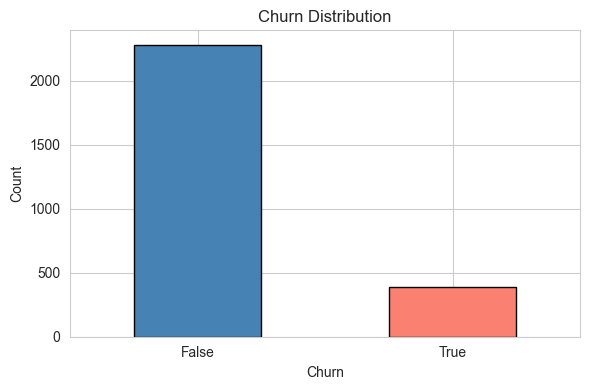

In [4]:
# How balanced is our target variable (Churn)?
churn_counts = df['Churn'].value_counts()
print(churn_counts)

plt.figure(figsize=(6, 4))
churn_counts.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 2. Histograms – Distribution of Numerical Features

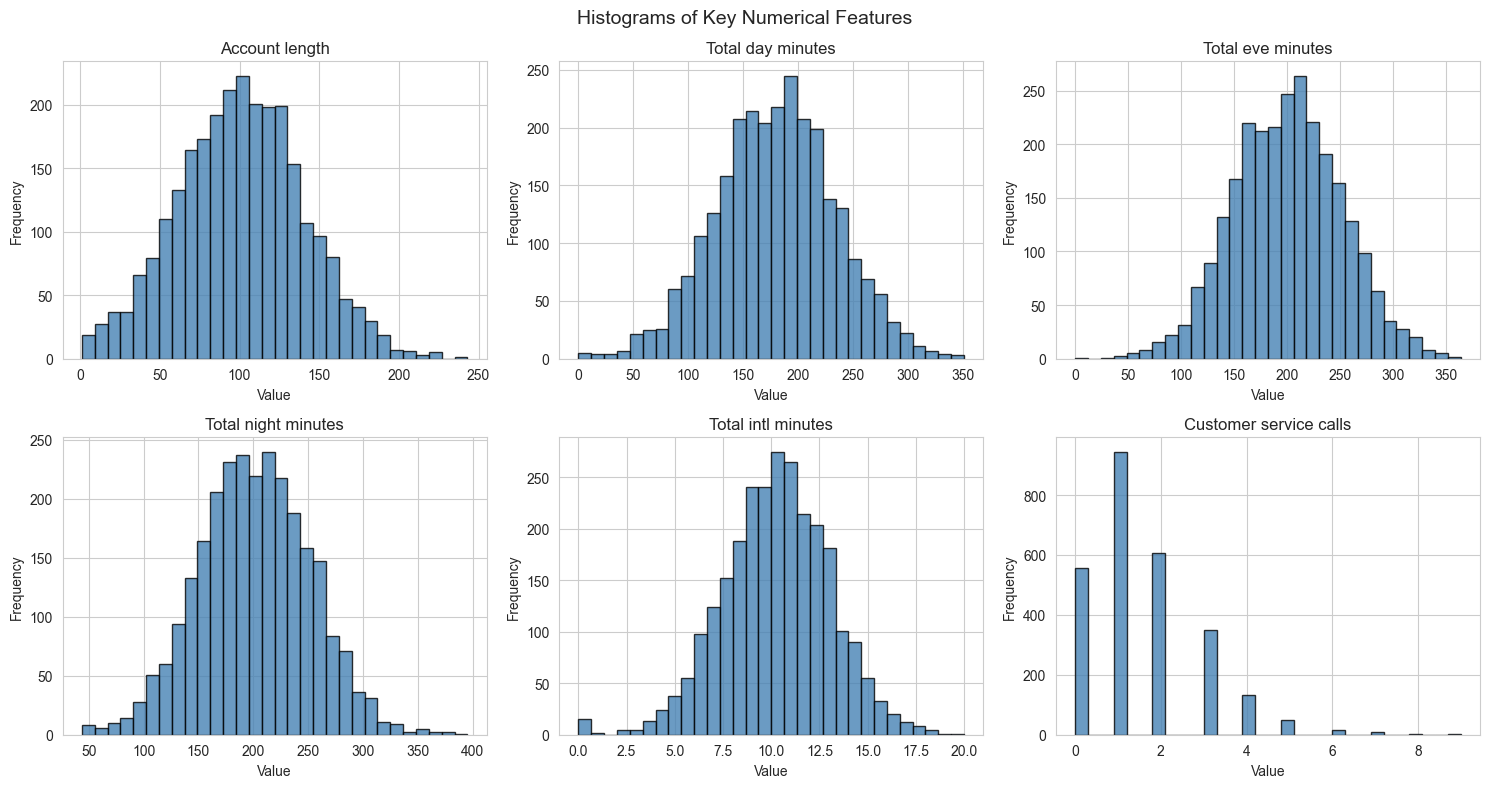

In [5]:
numeric_cols = ['Account length', 'Total day minutes', 'Total eve minutes',
                'Total night minutes', 'Total intl minutes', 'Customer service calls']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle("Histograms of Key Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()


## 3. Box Plots – Spotting Outliers

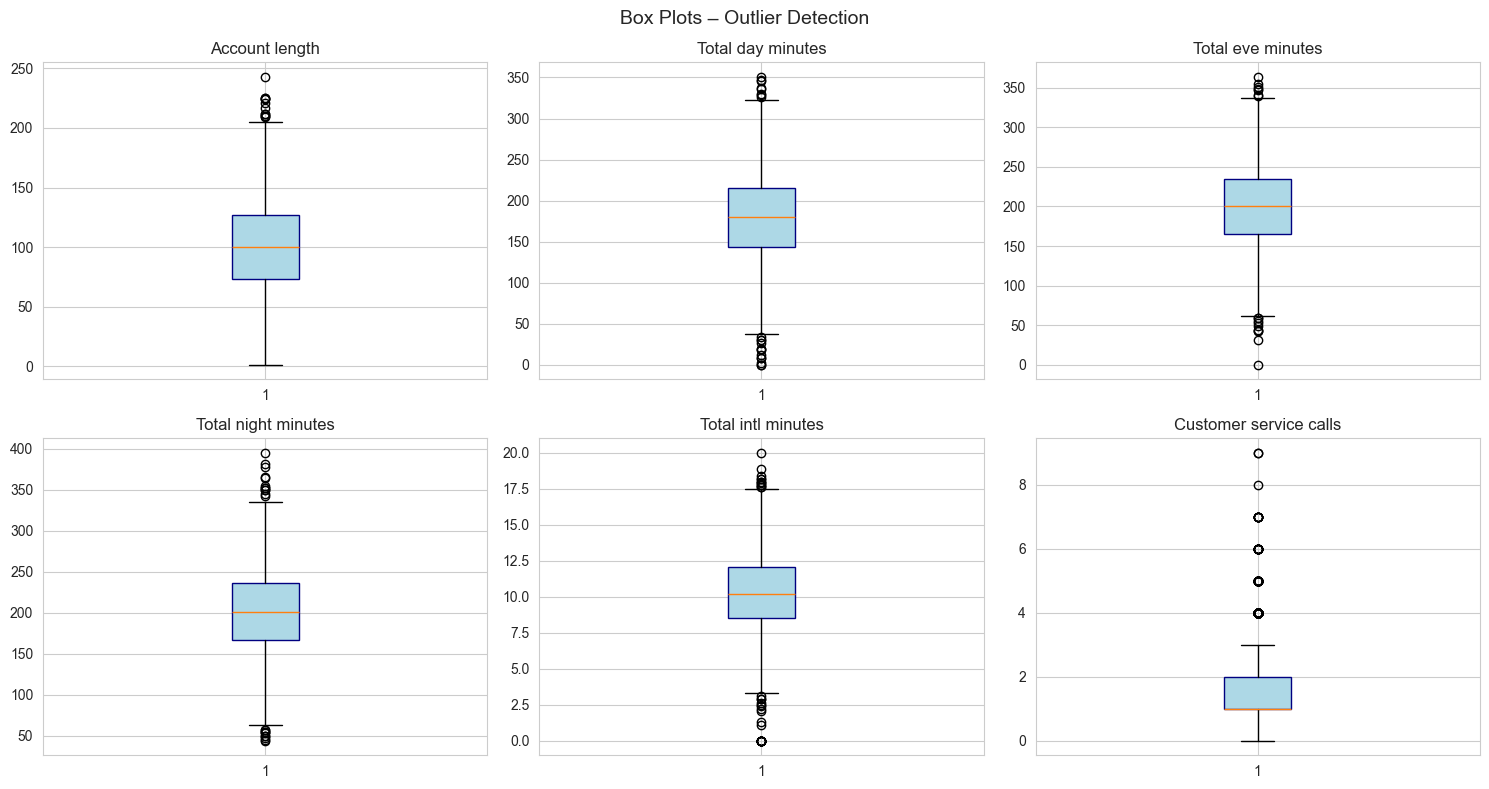

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'))
    axes[i].set_title(col)

plt.suptitle("Box Plots – Outlier Detection", fontsize=14)
plt.tight_layout()
plt.show()


## 4. Scatter Plots – Relationships Between Features

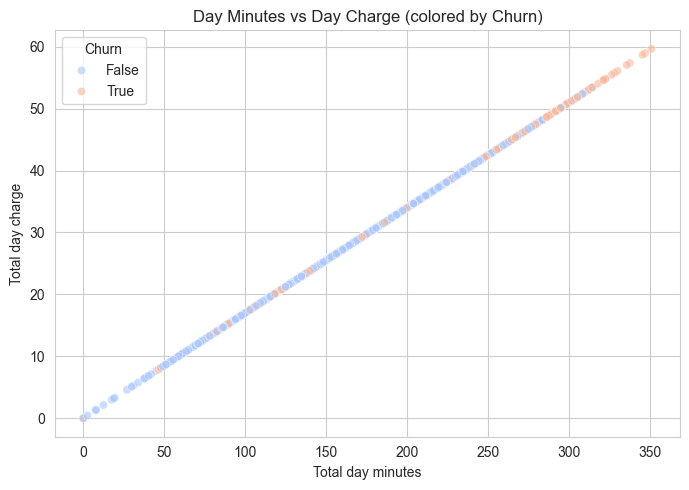

In [7]:
# Total day minutes vs Total day charge (should be strongly correlated)
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Total day minutes', y='Total day charge',
                hue='Churn', data=df, alpha=0.6, palette='coolwarm')
plt.title("Day Minutes vs Day Charge (colored by Churn)")
plt.tight_layout()
plt.show()


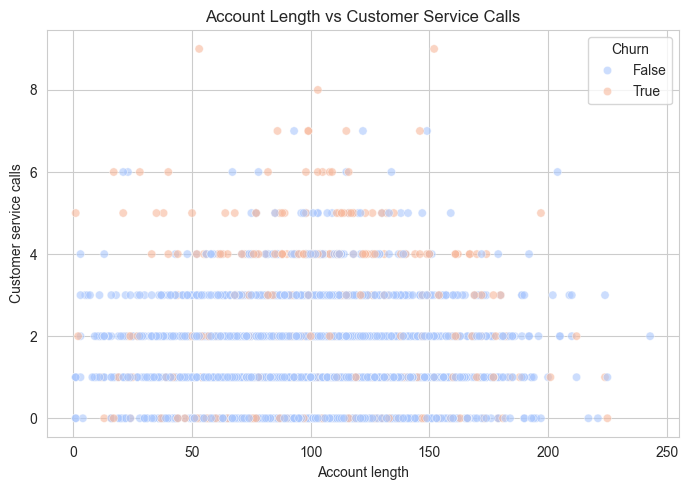

In [8]:
# Customer service calls vs Account length – any pattern?
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Account length', y='Customer service calls',
                hue='Churn', data=df, alpha=0.6, palette='coolwarm')
plt.title("Account Length vs Customer Service Calls")
plt.tight_layout()
plt.show()


## 5. Correlation Matrix

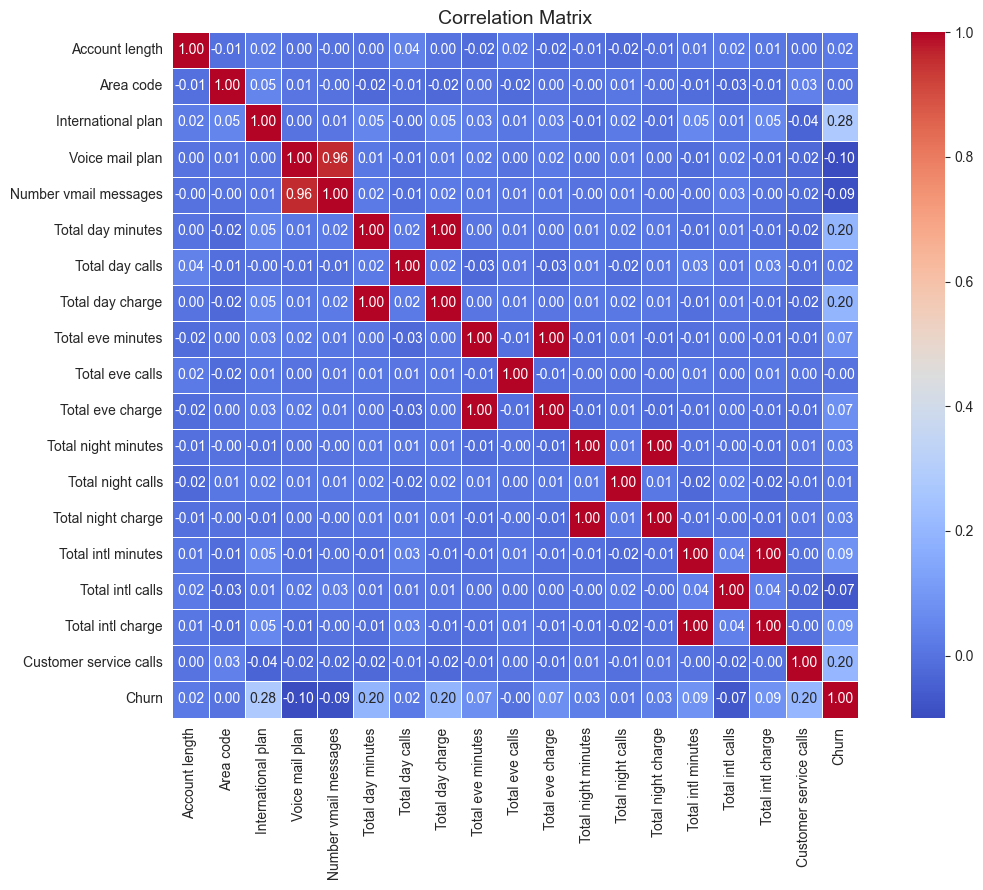

In [9]:
# Encode booleans first so they appear in the correlation matrix
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].astype(int)
df_corr['International plan'] = (df_corr['International plan'] == 'Yes').astype(int)
df_corr['Voice mail plan'] = (df_corr['Voice mail plan'] == 'Yes').astype(int)

corr_matrix = df_corr.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()


## 6. Churn vs Key Features

<Figure size 600x400 with 0 Axes>

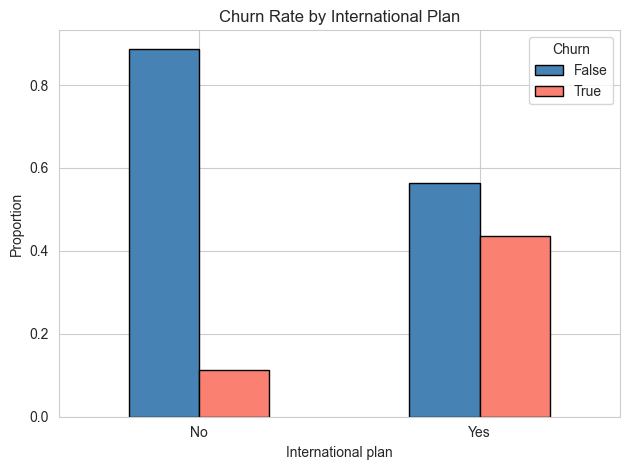

In [10]:
# Churn rate by International plan
plt.figure(figsize=(6, 4))
pd.crosstab(df['International plan'], df['Churn'], normalize='index').plot(
    kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title("Churn Rate by International Plan")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()


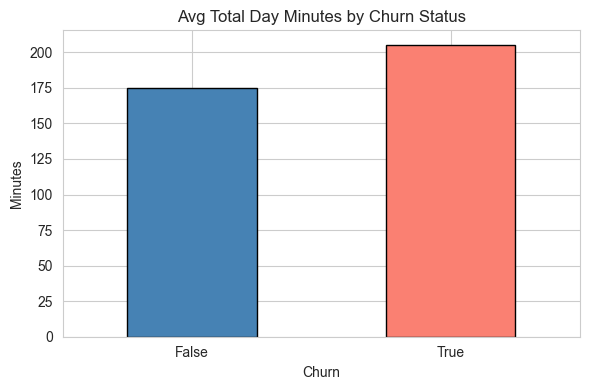

In [11]:
# Average day minutes by churn status
plt.figure(figsize=(6, 4))
df.groupby('Churn')['Total day minutes'].mean().plot(kind='bar',
    color=['steelblue', 'salmon'], edgecolor='black')
plt.title("Avg Total Day Minutes by Churn Status")
plt.ylabel("Minutes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## EDA Summary / Key Insights
1. **Class imbalance:** Only ~14% of customers churned – something to keep in mind for modeling.
2. **Strong correlations:** Total day minutes and Total day charge are nearly perfectly correlated (expected – charge is calculated from minutes).
3. **International plan matters:** Customers with an international plan churn at a significantly higher rate.
4. **Day usage:** Churned customers tend to use more daytime minutes on average.
5. **Customer service calls:** Customers who called support many times are more likely to churn – signals dissatisfaction.
